In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [168]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Housing.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/housing-prices-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_4667/2964430592.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
First 5 records:       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [169]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Tasks

*   Load the dataset using Pandas.
*   Select one feature (e.g., area) and the target variable (price). Convert them to NumPy arrays.
*   Implement the Mean Squared Error (MSE) Cost Function manually.
*   Calculate the initial cost using random values of slope and intercept.
*   Apply Gradient Descent from scratch.
*   Train for 1000 iterations.
*   **Plot:**
    *   Iteration vs. Cost
    *   Actual vs. Predicted Values
*   Report the final learned parameters.

In [170]:
X = np.array(df['area'])
y= np.array(df['price'])

In [171]:

def prediction(X, w, b):
  return w * X + b

In [172]:
prediction = prediction(X,w=1,b=1)

In [173]:
print(prediction)

[ 7421  8961  9961  7501  7421  7501  8581 16201  8101  5751 13201  6001
  6551  3501  7801  6001  6601  8501  4601  6421  4321  7156  8051  4561
  8801  6541  6001  8876  7951  5501  7476  7001  4881  5961  6841  7001
  7483  9001  6001  6001  6551  6361  6481  6001  6001  6001  6001  6601
  4301  7441  7441  6326  6001  5151  6001  6001 11441  9001  7681  6001
  6001  8881  6241  6361 11176  8881 13201  7701  6001 12091  4001  6001
  5021  6601  4041  4261  6421  6501  5701  6001  6001  4001 10501  6001
  3761  8251  6671  3961  7411  8581  5001  6751  4801  7201  6001  4101
  9001  6401  6601  6001  6601  5501  5501  6351  5501  4501  5451  6421
  3241  6616  6601  8373  4301  9621  6801  8001  6901  3701  6421  7021
  6541  7232  6255  7321  6526 15601  7161  6501  5501 11461  4801  5829
  5201  4801  7001  6001  5401  4641  5001  6361  5801  6661 10501  4801
  4701  5001 10501  5501  6361  6601  5137  4401  5401  3301  3651  6101
  6901  2818  7981  3151  6211  6101  6601  6826  6

- First calculate  cost J(w,b)
- then dj_dw and dj_db
- then gradiant function m = m - alpha * dj_dm
- and b = b - alpha * dj_db

In [174]:
def compute_cost(X, y, w, b):
  m = X.shape[0]
  predictions = prediction(X, w, b)
  cost = (1/(2*m)) * np.sum((predictions - y)**2)
  return cost

In [175]:

# --- Data Normalization (Crucial for Gradient Descent with large values) ---

X_normalized = (X - np.mean(X)) / np.std(X)
y_normalized = (y - np.mean(y)) / np.std(y)

In [176]:
# --- Initial Cost Calculation ---

# Redefine the 'prediction' function as it was overwritten in a previous cell.
def prediction(X, w, b):
  return w * X + b

w_initial = 0.0
b_initial = 0.0
initial_cost = compute_cost(X_normalized, y_normalized, w_initial, b_initial)
print(f"Initial Cost (w={w_initial}, b={b_initial}): {initial_cost:.4f}")

Initial Cost (w=0.0, b=0.0): 0.5000


In [177]:
# --- 3. Gradient Descent Algorithm ---
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):

  m = X.shape[0]
  J_history = []
  w = w_in
  b = b_in

  for i in range(num_iters):
    predictions = prediction(X, w, b)

    # Calculate gradients
    dj_dw = (1/m) * np.sum((predictions - y) * X)
    dj_db = (1/m) * np.sum(predictions - y)

    # Update parameters
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # Save cost at each iteration
    J_history.append(compute_cost(X, y, w, b))

  return w, b, J_history

In [178]:
# --- 4. Train for 1000 iterations ---
learning_rate = 0.01
iterations = 1000

w_final, b_final, J_hist = gradient_descent(X_normalized, y_normalized, w_initial, b_initial, learning_rate, iterations)

In [179]:
# --- Report the final learned parameters ---
print(f"\nAfter {iterations} iterations:")
print(f"Final w (normalized): {w_final:.4f}")
print(f"Final b (normalized): {b_final:.4f}")
print(f"Final Cost: {J_hist[-1]:.4f}")



After 1000 iterations:
Final w (normalized): 0.5360
Final b (normalized): 0.0000
Final Cost: 0.3564


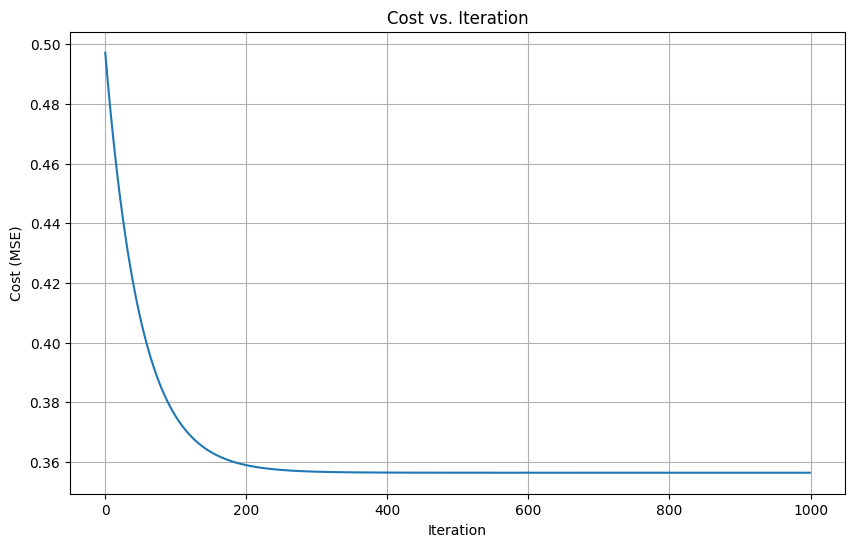

In [180]:
# --- 5. Plot: Iteration vs Cost ---
plt.figure(figsize=(10, 6))
plt.plot(np.arange(iterations), J_hist)
plt.title('Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()

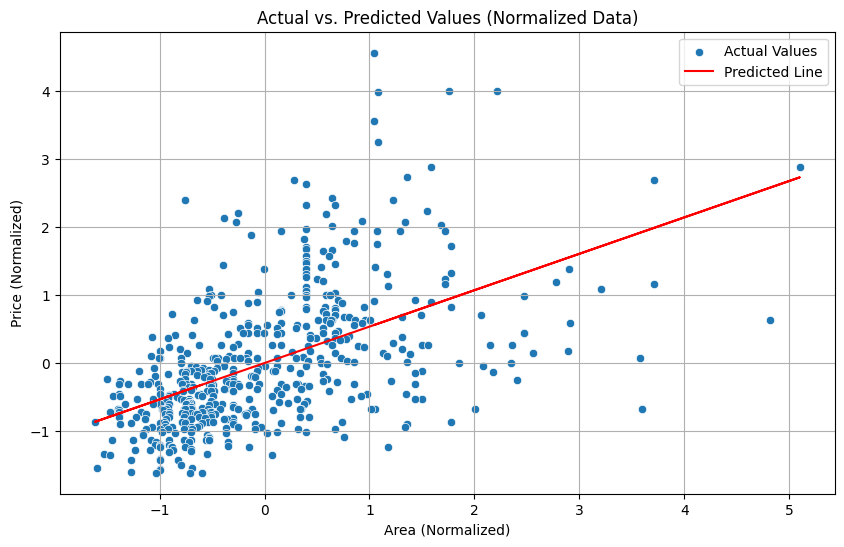

In [181]:

# --- 6. Plot: Actual vs Predicted Values ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_normalized, y=y_normalized, label='Actual Values')
plt.plot(X_normalized, prediction(X_normalized, w_final, b_final), color='red', label='Predicted Line')
plt.title('Actual vs. Predicted Values (Normalized Data)')
plt.xlabel('Area (Normalized)')
plt.ylabel('Price (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

### **Predict math score using reading score**

To predict 'math score' using 'reading score' from the dataframe, you would typically follow these steps:

1.  **Extract Data**: Select the 'reading score' column as your independent variable (X) and 'math score' as your dependent variable (y). Convert these Pandas Series into NumPy arrays for numerical operations.
    *   **Note**: Based on the current dataframe, the available columns are `price`, `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, and `furnishingstatus`. If you wish to proceed with a prediction task using these columns, please specify which ones you'd like to use.

2.  **Normalization (Optional but Recommended)**: For better performance and stability of Gradient Descent, normalize your data (X and y). This usually involves scaling them to have a mean of 0 and a standard deviation of 1.

### **Implement the MSE Cost Function Manually**

The Mean Squared Error (MSE) cost function is a common metric used to quantify the difference between predicted values and actual values. For a simple linear regression model where `prediction = w * X + b` (where `w` is the weight/slope and `b` is the bias/intercept), the MSE is calculated as:

$$ J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (prediction^{(i)} - y^{(i)})^2 $$

Where:

*   `m` is the number of training examples.
*   `prediction^(i)` is the predicted value for the i-th example.
*   `y^(i)` is the actual value for the i-th example.
*   The `1/2m` factor is used to simplify the derivative calculation.

### **Compute the Gradient Formulas Manually**

Gradient Descent works by iteratively adjusting the parameters `w` and `b` in the direction that reduces the cost function. This direction is given by the negative of the gradient of the cost function with respect to `w` and `b`.

The partial derivatives of the MSE cost function with respect to `w` and `b` are:

*   **Gradient with respect to `w` (dj_dw)**:

    $$ \frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (prediction^{(i)} - y^{(i)}) X^{(i)} $$

*   **Gradient with respect to `b` (dj_db)**:

    $$ \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (prediction^{(i)} - y^{(i)}) $$

### **Perform Gradient Descent for 500 iterations**

Gradient Descent involves updating `w` and `b` iteratively using the calculated gradients and a `learning_rate` (`α`). The update rules are:

$$ w = w - \alpha \cdot \frac{\partial J}{\partial w} $$
$$ b = b - \alpha \cdot \frac{\partial J}{\partial b} $$

This process is repeated for a specified number of `iterations` (e.g., 500).

### **Print the cost after every 50 iterations**

During Gradient Descent, it's good practice to keep track of the cost function's value at each iteration. To print the cost every 50 iterations, you would include a conditional statement inside your gradient descent loop:

```python
if i % 50 == 0:
    cost = compute_cost(X, y, w, b)
    print(f"Iteration {i}: Cost = {cost:.4f}")
```

### **Plot Cost vs Iteration**

To visualize how the cost function decreases over iterations, you can plot the `J_history` (a list containing the cost at each iteration) against the iteration number. This helps to confirm that Gradient Descent is converging.

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(len(J_history)), J_history)
plt.title('Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()
```

# ***Student Dataset***

In [182]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "StudentsPerformance.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "spscientist/students-performance-in-exams",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_4667/2498332662.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 70.3k/70.3k [00:00<00:00, 1.01MB/s]

First 5 records:    gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [183]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [184]:
X = np.array(df['reading score'])
y= np.array(df['math score'])

In [185]:
def compute_cost(X,y, w, b):
  m = X.shape[0]
  predictions = prediction(X, w, b)
  cost = (1/(2*m)) * np.sum((predictions - y)**2)
  return cost

In [186]:
x_normalize = (X - np.mean(X))/ np.std(X)
y_normalize = (y - np.mean(y))/ np.std(y)

In [187]:
# --- Initial Cost Calculation ---

# Redefine the 'prediction' function as it was overwritten in a previous cell.
def prediction(X, w, b):
  return w * X + b

w_initial = 0.0
b_initial = 0.0
initial_cost = compute_cost(x_normalize, y_normalize, w_initial, b_initial)
print(f"Initial Cost (w={w_initial}, b={b_initial}): {initial_cost:.4f}")

Initial Cost (w=0.0, b=0.0): 0.5000


In [188]:
# --- 3. Gradient Descent Algorithm ---
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):

  m = X.shape[0]
  J_history = []
  w = w_in
  b = b_in

  """
  Gradiant decent,

  # For w,
  w_new = w_old - alpha * dj_dw
  For b,
  w_new = w_old - alpha * dj_db

  # Gradiant
  dj_dw = (1/m) * sum((pred_y - y-test)*x)
  dj-db = (1/m) * sum(pred_y - y_test)

  # Cost Function
  cost_func = (2/m)* sum((pred_y - y_test)**2)

  # Prediction
  prediction = w*x + b
  """

  for i in range(num_iters):
    predictions = prediction(X, w, b)

    # Calculate gradients
    dj_dw = (1/m) * np.sum((predictions - y) * X)
    dj_db = (1/m) * np.sum(predictions - y)

    # Update parameters
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # Save cost at each iteration
    J_history.append(compute_cost(X, y, w, b))

  return w, b, J_history

In [189]:
# --- 4. Train for 1000 iterations ---
learning_rate = 0.01
iterations = 1000

w_final, b_final, J_hist = gradient_descent(X_normalized, y_normalized, w_initial, b_initial, learning_rate, iterations)

In [190]:
# --- Report the final learned parameters ---
print(f"\nAfter {iterations} iterations:")
print(f"Final w (normalized): {w_final:.4f}")
print(f"Final b (normalized): {b_final:.4f}")
print(f"Final Cost: {J_hist[-1]:.4f}")



After 1000 iterations:
Final w (normalized): 0.5360
Final b (normalized): 0.0000
Final Cost: 0.3564


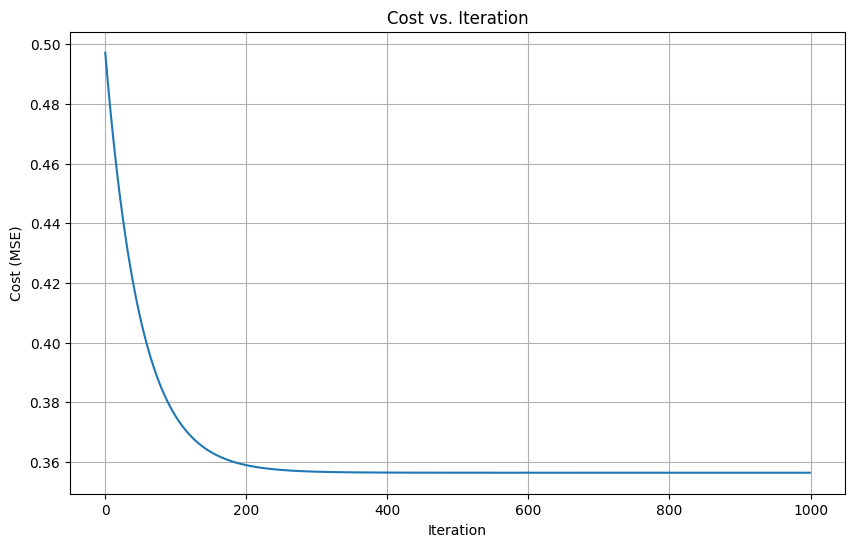

In [191]:
# --- 5. Plot: Iteration vs Cost ---
plt.figure(figsize=(10, 6))
plt.plot(np.arange(iterations), J_hist)
plt.title('Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()

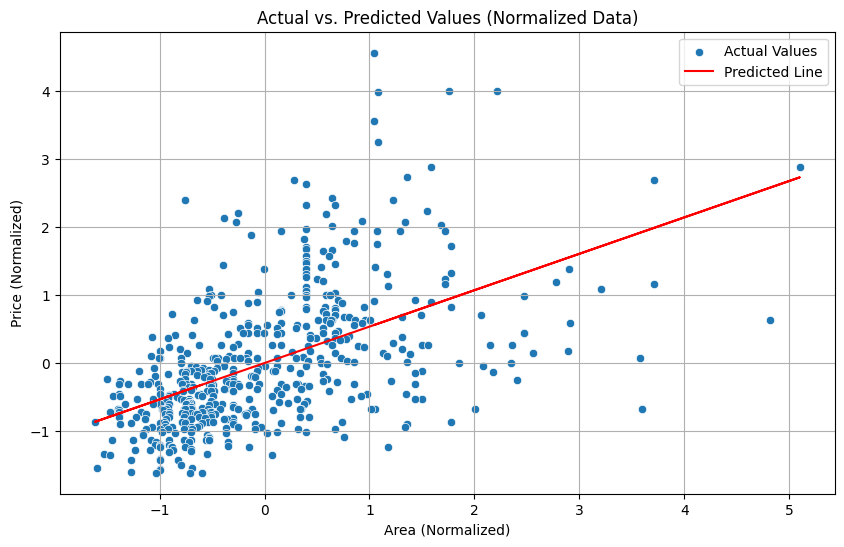

In [192]:

# --- 6. Plot: Actual vs Predicted Values ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_normalized, y=y_normalized, label='Actual Values')
plt.plot(X_normalized, prediction(X_normalized, w_final, b_final), color='red', label='Predicted Line')
plt.title('Actual vs. Predicted Values (Normalized Data)')
plt.xlabel('Area (Normalized)')
plt.ylabel('Price (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [193]:
pip install ucimlrepo

In [194]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auto_mpg = fetch_ucirepo(id=9)

# data (as pandas dataframes)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# metadata
print(auto_mpg.metadata)

# variable information
print(auto_mpg.variables)


{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

In [195]:
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [196]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [197]:
x = auto_mpg.data.features['horsepower']

In [198]:
def compute_cost(X,y, w, b):
  m = X.shape[0]
  predictions = prediction(X, w, b)
  cost = (1/(2*m)) * np.sum((predictions - y)**2)
  return cost

In [199]:
Mse_for_car = compute_cost(x, auto_mpg.data.targets['mpg'], 5, 5)

In [200]:
Mse_for_car.max()

np.float64(144416.72077889447)

In [201]:
x_normalize = (x - np.mean(x))/ np.std(x)
y_normalize = (y - np.mean(y))/ np.std(y)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [202]:
# --- 4. Train for 1000 iterations ---
learning_rate = 0.01
iterations = 1000

w_final, b_final, J_hist = gradient_descent(X_normalized, y_normalized, w_initial, b_initial, learning_rate, iterations)

In [203]:
w_final

np.float64(0.5359742061040541)

In [204]:
# --- 4. Train for 1000 iterations ---
learning_rate = 0.001
iterations = 1000

w_final, b_final, J_hist = gradient_descent(X_normalized, y_normalized, w_initial, b_initial, learning_rate, iterations)

In [205]:
w_final

np.float64(0.3389135740460994)

In [206]:
# --- 4. Train for 1000 iterations ---
learning_rate = 0.1
iterations = 1000

w_final, b_final, J_hist = gradient_descent(X_normalized, y_normalized, w_initial, b_initial, learning_rate, iterations)

In [207]:
w_final

np.float64(0.5359973457780796)